In [3]:
import os

for dirname, subdirs, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/pabodhamallawa
/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release
/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release
/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_masks
/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_images


In [46]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.4 MB/s eta 0:00:00


In [13]:
import cv2
import matplotlib.pyplot as plt

In [8]:
mask_dir = "/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_masks"
image_dir = "/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_images"

train_images = os.listdir(image_dir)
train_masks = os.listdir(mask_dir)

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

print(f"Number of training images: {len(train_images)}")
print(f"Number of training masks: {len(train_masks)}")

Number of training images: 2000
Number of training masks: 2000


In [39]:
def display_sample(idx):
    "Display image, mask, and overlap"

    # paths
    img_path = os.path.join(image_dir, image_files[idx])
    mask_path = os.path.join(mask_dir, mask_files[idx])

    # read image & mask
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # normalize mask (0 or 1)
    mask_norm = mask / 255.0

    # create colored overlay (red mask)
    overlay = img.copy()
    overlay[mask_norm > 0] = [0, 255, 255]

    # blend image and overlay
    alpha = 0.5
    blended = cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    ax[0].imshow(img)
    ax[0].set_title(f"Image {idx}")
    ax[0].axis('off')

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Mask")
    ax[1].axis('off')

    ax[2].imshow(blended)
    ax[2].set_title("Overlay")
    ax[2].axis('off')

    plt.tight_layout()
    display(fig)
    plt.close()

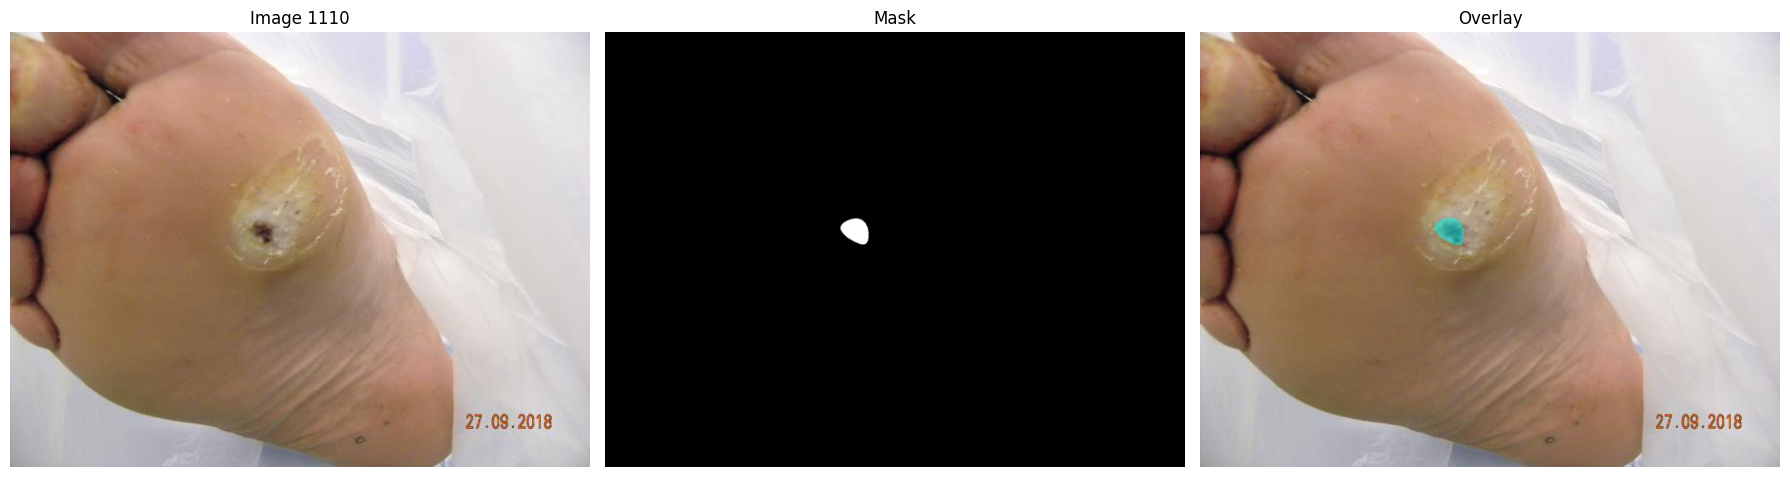

In [40]:
display_sample(1110)

In [41]:
#### TRAINING

import pandas as pd
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

In [42]:
# Create a DataFrame of paths
images = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)])
masks = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])

df = pd.DataFrame({'image': images, 'mask': masks})

# Shuffle Whole dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Train (75%) + Temp (25%)
train_df, temp_df = train_test_split(df, test_size=0.25, random_state=42)

# Temp → Val (15%) + Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.4, random_state=42)

# Check sizes
print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 1500
Val: 300
Test: 200


In [43]:
# Data Augmentation on Train

# Train
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Validation (no augmentation)
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Test (same as validation)
test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [44]:
import torch
from torch.utils.data import Dataset, DataLoader

# Dataset Class
class DFUDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image']
        mask_path = self.df.iloc[idx]['mask']

        # Read image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)   # Binary mask (0/1)

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Add channel dimension to mask → (1, H, W)
        mask = mask.unsqueeze(0)

        return image, mask


# Create Dataset Objects
train_dataset = DFUDataset(train_df, transform=train_transform)
val_dataset   = DFUDataset(val_df, transform=val_transform)
test_dataset  = DFUDataset(test_df, transform=test_transform)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


images, masks = next(iter(train_loader))

print("Image shape:", images.shape)   # Expected: (B, 3, 256, 256)
print("Mask shape:", masks.shape)     # Expected: (B, 1, 256, 256)

Image shape: torch.Size([16, 3, 256, 256])
Mask shape: torch.Size([16, 1, 256, 256])


In [55]:
import segmentation_models_pytorch as smp

# Choosing U-Net with a ResNet34 backbone
model = smp.Unet(
    encoder_name="resnet34",        # Backbone
    encoder_weights="imagenet",     # Pre-trained weights
    in_channels=3,                  # RGB input
    classes=1,                      # Binary segmentation
    activation=None                 # We will use Sigmoid in our loss
)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [56]:
## LOSSES

# Dice Loss (handles overlap)
dice_loss = smp.losses.DiceLoss(
    mode='binary',      # binary segmentation
    from_logits=True    # because model output = raw logits
)

# BCE Loss (pixel-wise accuracy)
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

# Combined Loss
def criterion(y_pred, y_true):
    y_true = y_true.float()
    return dice_loss(y_pred, y_true) + bce_loss(y_pred, y_true)


def dice_coef(y_pred, y_true, threshold=0.5):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > threshold).float()
    y_true = y_true.float()

    intersection = (y_pred * y_true).sum(dim=(1,2,3))
    union = y_pred.sum(dim=(1,2,3)) + y_true.sum(dim=(1,2,3))

    dice = (2. * intersection) / (union + 1e-7)
    return dice.mean()

In [57]:
# optimizer
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# schedular
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

#IoU
def iou_score(y_pred, y_true, threshold=0.5):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > threshold).float()
    y_true = y_true.float()

    intersection = (y_pred * y_true).sum(dim=(1,2,3))
    union = y_pred.sum(dim=(1,2,3)) + y_true.sum(dim=(1,2,3)) - intersection

    iou = (intersection) / (union + 1e-7)
    return iou.mean()


In [58]:
import os
from tqdm import tqdm
import torch
import numpy as np

# Create checkpoint folder
os.makedirs("checkpoints", exist_ok=True)

epochs = 20
best_dice = 0.0

history = {
    'train_loss': [],
    'val_loss': [],
    'val_dice': [],
    'val_iou': []
}

for epoch in range(epochs):
    # ================= TRAIN =================
    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            val_loss += criterion(outputs, masks).item()
            total_dice += dice_coef(outputs, masks).item()
            total_iou += iou_score(outputs, masks).item()

    # ================= METRICS =================
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = total_dice / len(val_loader)
    avg_val_iou = total_iou / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_dice'].append(avg_val_dice)
    history['val_iou'].append(avg_val_iou)

    print(f"\nSummary:")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss  : {avg_val_loss:.4f}")
    print(f"Val Dice  : {avg_val_dice:.4f}")
    print(f"Val IoU   : {avg_val_iou:.4f}")

    # ================= SCHEDULER =================
    scheduler.step(avg_val_loss)

    # ================= CHECKPOINTS =================
    checkpoint_path = f"checkpoints/epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), checkpoint_path)

    # Save best model (based on Dice)
    if avg_val_dice > best_dice:
        best_dice = avg_val_dice
        torch.save(model.state_dict(), "best_model.pth")
        print("🟢 Best model saved!")


Epoch 1/20: 100%|██████████| 94/94 [00:22<00:00,  4.18it/s, loss=1.05] 



Summary:
Train Loss: 1.2536
Val Loss  : 1.0618
Val Dice  : 0.5523
Val IoU   : 0.4289
🟢 Best model saved!


Epoch 2/20: 100%|██████████| 94/94 [00:21<00:00,  4.43it/s, loss=0.813]



Summary:
Train Loss: 0.9763
Val Loss  : 0.9000
Val Dice  : 0.5738
Val IoU   : 0.4458
🟢 Best model saved!


Epoch 3/20: 100%|██████████| 94/94 [00:20<00:00,  4.67it/s, loss=0.573]


...


Summary:
Train Loss: 0.1660
Val Loss  : 0.2443
Val Dice  : 0.6937
Val IoU   : 0.5920


Epoch 19/20: 100%|██████████| 94/94 [00:20<00:00,  4.59it/s, loss=0.176] 



Summary:
Train Loss: 0.1714
Val Loss  : 0.2205
Val Dice  : 0.7262
Val IoU   : 0.6272
🟢 Best model saved!


Epoch 20/20: 100%|██████████| 94/94 [00:20<00:00,  4.59it/s, loss=0.192] 



Summary:
Train Loss: 0.1614
Val Loss  : 0.2425
Val Dice  : 0.7008
Val IoU   : 0.6011


In [63]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(15, 5))

    # ---------------- Loss ----------------
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # ---------------- Dice ----------------
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_dice'], label='Val Dice', color='green')
    plt.title("Dice Score")
    plt.xlabel("Epochs")
    plt.ylabel("Dice")
    plt.legend()

    # ---------------- IoU ----------------
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['val_iou'], label='Val IoU', color='orange')
    plt.title("IoU Score")
    plt.xlabel("Epochs")
    plt.ylabel("IoU")
    plt.legend()

    plt.tight_layout()
    plt.show()

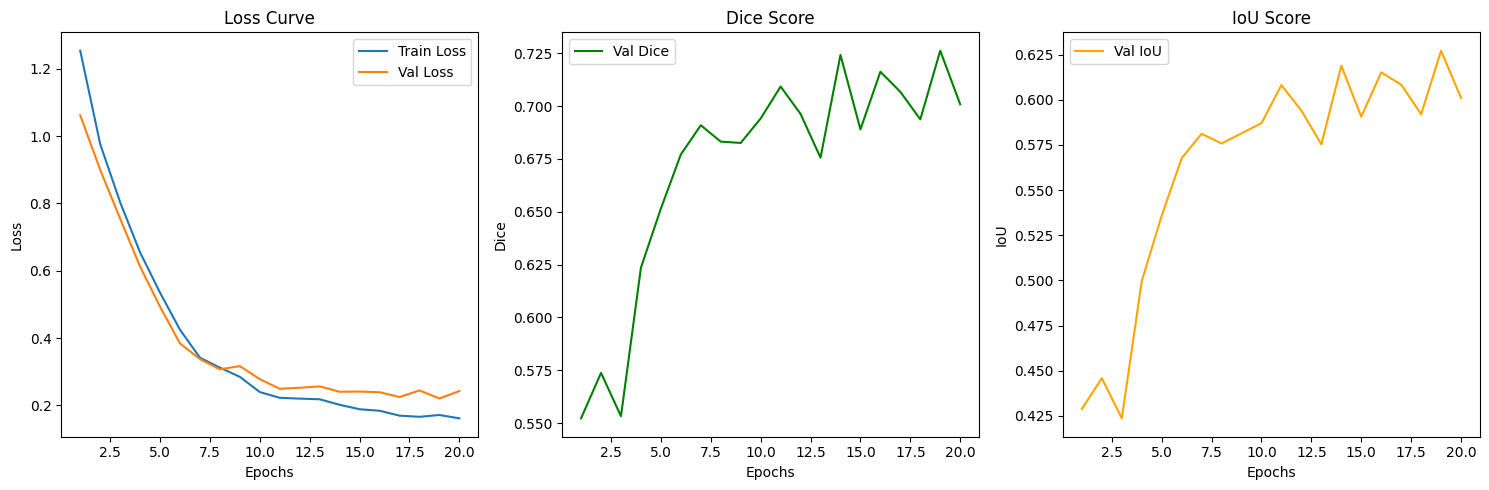

In [64]:
plot_training_history(history)

In [65]:
def evaluate_model(model, dataloader, device):
    model.eval()

    total_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)
            total_loss += loss.item()

            total_dice += dice_coef(outputs, masks).item()
            total_iou += iou_score(outputs, masks).item()

    avg_loss = total_loss / len(dataloader)
    avg_dice = total_dice / len(dataloader)
    avg_iou = total_iou / len(dataloader)

    print("\n📊 Test Results:")
    print(f"Test Loss : {avg_loss:.4f}")
    print(f"Test Dice : {avg_dice:.4f}")
    print(f"Test IoU  : {avg_iou:.4f}")

    return avg_loss, avg_dice, avg_iou

In [66]:
evaluate_model(model, test_loader, device)


📊 Test Results:
Test Loss : 0.2344
Test Dice : 0.6972
Test IoU  : 0.5958


(0.23442200284737807, 0.6971907707361075, 0.5958465360678159)

In [80]:
def predict_image(model, image_path, transform, device, threshold=0.5):
    model.eval()

    # Load Image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image not found: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original = image.copy()

    # Preprocess 
    augmented = transform(image=image)
    image_tensor = augmented['image'].unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(image_tensor)
        pred = torch.sigmoid(output)
        pred = (pred > threshold).float()

    # Convert to numpy 
    mask = pred.squeeze().cpu().numpy()

    # Resize mask back to original size 
    mask = cv2.resize(mask, (original.shape[1], original.shape[0]))

    # Create overlay (cyan)
    overlay = original.copy()
    overlay[mask > 0] = [0, 255, 255]

    # 🔥 Alpha blending
    alpha = 0.5
    blended = cv2.addWeighted(original, 1 - alpha, overlay, alpha, 0)

    # Plot
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")
    
    plt.subplot(1,3,3)
    plt.imshow(blended)
    plt.title("Overlay")
    plt.axis("off")
    
    plt.show()

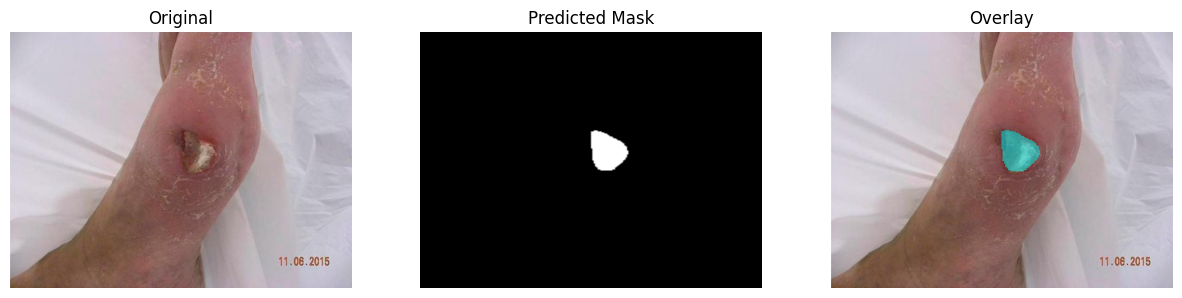

In [82]:
img_path_pre = os.path.join(image_dir,"100100.jpg")

predict_image(
    model,
    img_path_pre,
    val_transform,   # IMPORTANT: val transform
    device
)

In [83]:
from IPython.display import FileLink
FileLink(r'best_model.pth')

/kaggle/working/best_model.pth